# Impact of Lifestyle and Clinical Factors on Diabetes and Obesity Risk

This notebook analyzes the CDC Diabetes Health Indicators dataset. It performs Exploratory Data Analysis (EDA), preprocesses the data, trains machine learning models to predict the risk of Diabetes and Obesity, and provides an interactive section to input your own test data and calculate your risk percentages.

In [1]:
!pip install -q ucimlrepo pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 2. Load and Combine Dataset
We use the `ucimlrepo` package to download the CDC Diabetes Health Indicators dataset directly. This is a very clean and official way to download real-world dataset. We will combine the features and targets, and create a new feature for `Obesity` based on the `BMI`.

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# Fetch dataset 
print("Downloading Dataset...")
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# Data (as pandas dataframes) 
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets 

# Combine into a single DataFrame
df = pd.concat([X, y], axis=1)

# The dataset has BMI. Let's create an 'Obesity' column (BMI >= 30 is generally considered obese)
df['Obesity'] = (df['BMI'] >= 30).astype(int)

print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded with 253680 rows and 23 columns.


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary,Obesity
0,1,1,1,40,1,0,0,0,0,1,...,5,18,15,1,0,9,4,3,0,1
1,0,0,0,25,1,0,0,1,0,0,...,3,0,0,0,0,7,6,1,0,0
2,1,1,1,28,0,0,0,0,1,0,...,5,30,30,1,0,9,4,8,0,0
3,1,0,1,27,0,0,0,1,1,1,...,2,0,0,0,0,11,3,6,0,0
4,1,1,1,24,0,0,0,1,1,1,...,2,3,0,0,0,11,5,4,0,0


## 3. Baseline Percentages of Diabetes, Obesity, and Both
Let's answer the core question: what is the percentage of people with Diabetes, Obesity, and both in this dataset?

Percentage of people with Diabetes: 13.93%
Percentage of people with Obesity: 34.63%
Percentage of people with BOTH Diabetes and Obesity: 8.10%


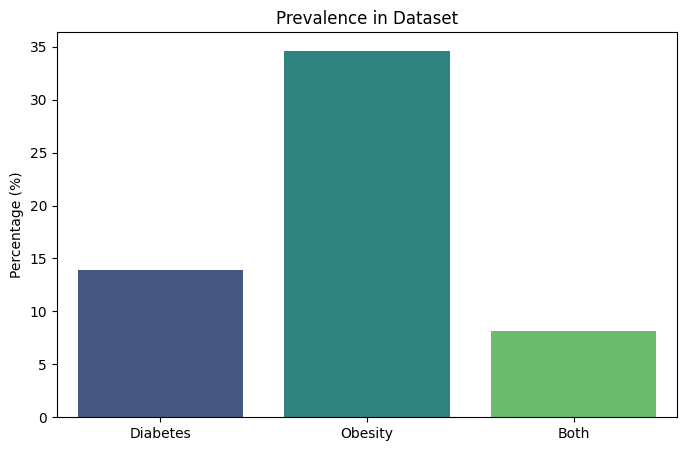

In [4]:
diabetes_pct = df['Diabetes_binary'].mean() * 100
obesity_pct = df['Obesity'].mean() * 100
both_pct = ((df['Diabetes_binary'] == 1) & (df['Obesity'] == 1)).mean() * 100

print(f"Percentage of people with Diabetes: {diabetes_pct:.2f}%")
print(f"Percentage of people with Obesity: {obesity_pct:.2f}%")
print(f"Percentage of people with BOTH Diabetes and Obesity: {both_pct:.2f}%")

labels = ['Diabetes', 'Obesity', 'Both']
values = [diabetes_pct, obesity_pct, both_pct]

plt.figure(figsize=(8, 5))
sns.barplot(x=labels, y=values, palette='viridis')
plt.title('Prevalence in Dataset')
plt.ylabel('Percentage (%)')
plt.show()

## 4. Exploratory Data Analysis (EDA)
Let's visualize the relationships between lifestyle factors, diabetes, and obesity.

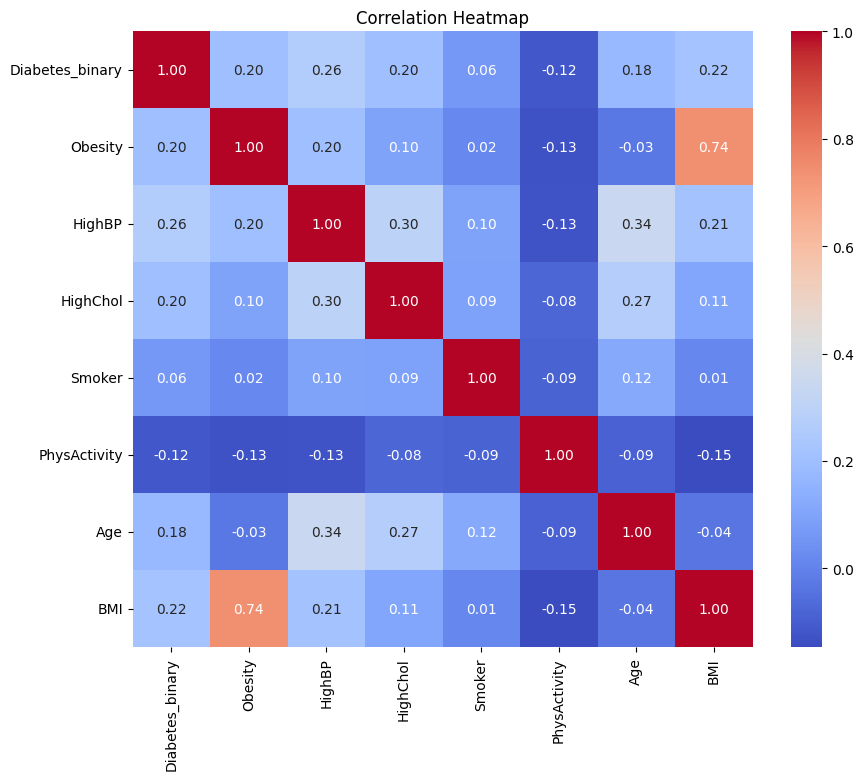

In [5]:
# Plotting the correlation heatmap for key variables
cols_of_interest = ['Diabetes_binary', 'Obesity', 'HighBP', 'HighChol', 'Smoker', 'PhysActivity', 'Age', 'BMI']
corr = df[cols_of_interest].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

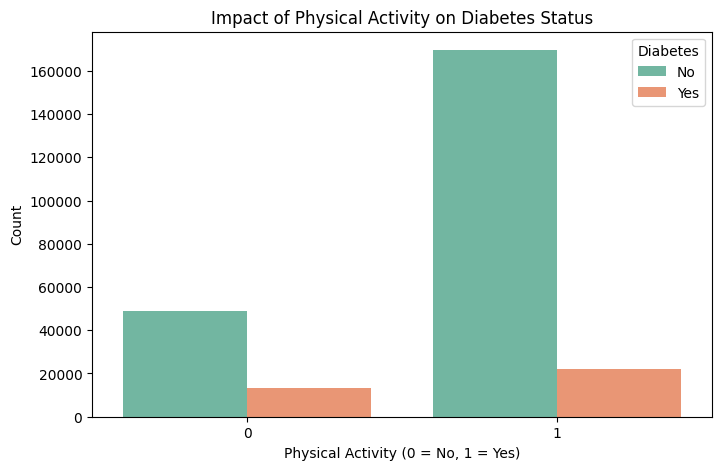

In [6]:
# Impact of Physical Activity on Diabetes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='PhysActivity', hue='Diabetes_binary', palette='Set2')
plt.title('Impact of Physical Activity on Diabetes Status')
plt.xlabel('Physical Activity (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(title='Diabetes', labels=['No', 'Yes'])
plt.show()

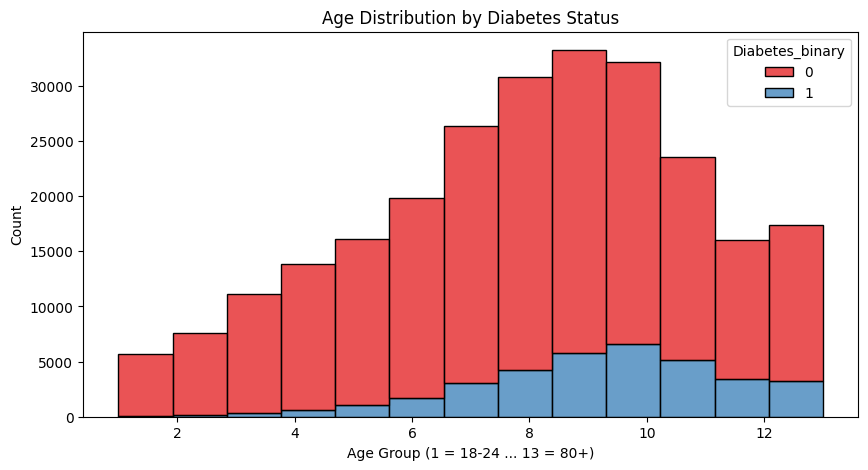

In [7]:
# Distribution of Age for Diabetics vs Non-Diabetics
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Diabetes_binary', multiple='stack', bins=13, palette='Set1')
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Age Group (1 = 18-24 ... 13 = 80+)')
plt.show()

## 5. Data Preprocessing
We need to scale our numerical features (like BMI) so that our machine learning models perform optimally. Here we'll show a **Before vs After** preprocessing graph.

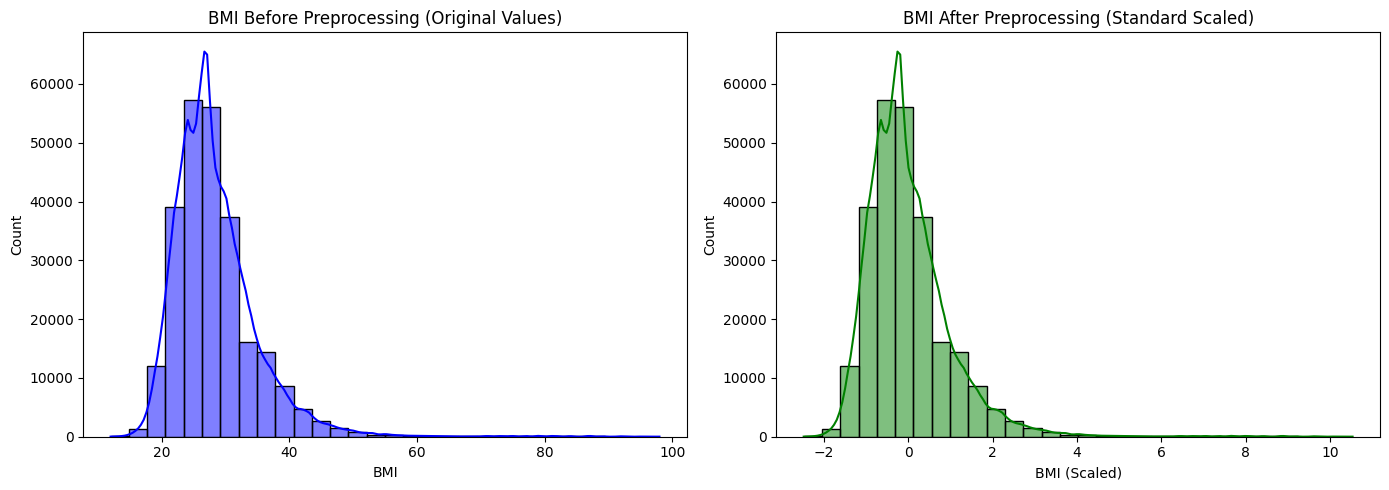

In [8]:
from sklearn.preprocessing import StandardScaler

# Create a copy for preprocessing
df_processed = df.copy()
features_to_scale = ['BMI', 'Age', 'MentHlth', 'PhysHlth']

# Keep original for 'before' plot
bmi_before = df['BMI'].copy()

scaler = StandardScaler()
df_processed[features_to_scale] = scaler.fit_transform(df_processed[features_to_scale])

bmi_after = df_processed['BMI']

# Plot Before and After Preprocessing (Scaling)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(bmi_before, kde=True, ax=axes[0], color='blue', bins=30)
axes[0].set_title('BMI Before Preprocessing (Original Values)')
axes[0].set_xlabel('BMI')

sns.histplot(bmi_after, kde=True, ax=axes[1], color='green', bins=30)
axes[1].set_title('BMI After Preprocessing (Standard Scaled)')
axes[1].set_xlabel('BMI (Scaled)')

plt.tight_layout()
plt.show()

## 6. Model Training
We will train Random Forest classifiers to predict the likelihood of both Diabetes and Obesity. Note: For brevity in this notebook, we'll train on a sampled subset if the dataset is very large.

In [9]:
# Sample the dataset for faster training in this demo (use full dataset in production)
df_sample = df_processed.sample(n=50000, random_state=42) 

# Define features and targets
X_model = df_sample.drop(columns=['Diabetes_binary', 'Obesity'])
y_diabetes = df_sample['Diabetes_binary']
y_obesity = df_sample['Obesity']

X_train, X_test, yd_train, yd_test, yo_train, yo_test = train_test_split(
    X_model, y_diabetes, y_obesity, test_size=0.2, random_state=42
)

print("Training Diabetes Model...")
rf_diabetes = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_diabetes.fit(X_train, yd_train)

print("Training Obesity Model...")
rf_obesity = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_obesity.fit(X_train, yo_train)

print("\n--- Diabetes Model Performance ---")
print(classification_report(yd_test, rf_diabetes.predict(X_test)))

print("\n--- Obesity Model Performance ---")
print(classification_report(yo_test, rf_obesity.predict(X_test)))

Training Diabetes Model...
Training Obesity Model...

--- Diabetes Model Performance ---
              precision    recall  f1-score   support

           0       0.87      0.99      0.93      8610
           1       0.61      0.11      0.18      1390

    accuracy                           0.87     10000
   macro avg       0.74      0.55      0.55     10000
weighted avg       0.84      0.87      0.82     10000


--- Obesity Model Performance ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6504
           1       1.00      1.00      1.00      3496

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## 7. Predict Your Own Risk
Provide your own test data in the dictionary below. The function will process your data and predict the percentage risk (probability) of having Diabetes, Obesity, and having BOTH.

In [10]:
def calculate_my_risk(user_input_dict):
    # Convert user input to DataFrame
    user_df = pd.DataFrame([user_input_dict])
    
    # Make sure we have all columns in the exact same order as training
    missing_cols = set(X_model.columns) - set(user_df.columns)
    for c in missing_cols:
        user_df[c] = 0 # Default fill for missing optional columns
        
    user_df = user_df[X_model.columns] # Reorder
    
    # Preprocess user data using the same scaler
    user_df[features_to_scale] = scaler.transform(user_df[features_to_scale])
    
    # Predict Probabilities (percentage)
    # predict_proba returns [prob_class_0, prob_class_1]
    prob_diabetes = rf_diabetes.predict_proba(user_df)[0][1] * 100
    prob_obesity = rf_obesity.predict_proba(user_df)[0][1] * 100
    
    # Assuming independence for the joint probability (simplest approach for user output)
    # Alternatively, you can use the dataset's correlation or just multiply probabilities
    prob_both = (prob_diabetes / 100) * (prob_obesity / 100) * 100
    
    print("="*40)
    print("      PREDICTION RESULTS (TEST DATA)")
    print("="*40)
    print(f"Risk of Diabetes:           {prob_diabetes:.2f}%")
    print(f"Risk of Obesity:            {prob_obesity:.2f}%")
    print(f"Risk of having BOTH:        {prob_both:.2f}%")
    print("="*40)
    print("(Note: These are probabilities based on the dataset, not a medical diagnosis.)")

# ==========================================
# INPUT YOUR TEST DATA HERE
# ==========================================
my_test_data = {
    'HighBP': 1,              # 0 = No, 1 = Yes
    'HighChol': 1,            # 0 = No, 1 = Yes
    'BMI': 32,                # Body Mass Index (e.g. 25, 30, 35)
    'Smoker': 0,              # 0 = No, 1 = Yes
    'Stroke': 0,              # 0 = No, 1 = Yes
    'HeartDiseaseorAttack': 0,# 0 = No, 1 = Yes
    'PhysActivity': 0,        # 0 = No, 1 = Yes
    'Fruits': 1,              # 1 = Consumes fruit daily
    'Veggies': 1,             # 1 = Consumes veggies daily
    'HvyAlcoholConsump': 0,   # 1 = Heavy drinker
    'GenHlth': 4,             # 1 = Excellent -> 5 = Poor
    'MentHlth': 2,            # Days of poor mental health in past 30 days
    'PhysHlth': 5,            # Days of poor physical health in past 30 days
    'DiffWalk': 0,            # 1 = Difficulty walking
    'Sex': 1,                 # 0 = Female, 1 = Male
    'Age': 9,                 # Age category (1 = 18-24, 9 = 60-64, 13 = 80+)
    'Education': 5,           # Education level (1-6)
    'Income': 6               # Income level (1-8)
}

calculate_my_risk(my_test_data)

      PREDICTION RESULTS (TEST DATA)
Risk of Diabetes:           40.38%
Risk of Obesity:            90.89%
Risk of having BOTH:        36.70%
(Note: These are probabilities based on the dataset, not a medical diagnosis.)
